In [16]:
import numpy as np
import matplotlib.pyplot as plt

def bvn(x, y, xmean, ymean, cov=np.array([[1,0],[0,1]])): 
    '''
    calculates bivariate density at x,y given means and covariance matrix
    x,y are coordinates, default covariance is variance 1 for both and no covariance (independent x and y)
    '''
    xy = np.array([[x],[y]])
    mu = np.array([[xmean],[ymean]])
    det = np.linalg.det(cov)
    inv = np.linalg.inv(cov)
    denom = np.sqrt(((2 * np.pi)**2) * det)
    num = np.e ** (-1/2 * (xy - mu).T @ inv @ (xy - mu))
    return (num/denom)[0][0] # index into a np.array([[v]]) to extract the value

def init_background_density(board, n):
    '''
    board = 2d grid
    uses bvn to stack n random gaussian distributions
    visualizes distribution at end via matplotlib imshow
    potential issues: can have lots of them stacked on top of each other
    '''
    board = np.copy(board)
    
    rng = np.random.default_rng()
    for dist in range(n):
        
        # generate a random center for the gaussian
        xmean = rng.integers(0, high=len(board[0])) # elements per row (number of columns)
        ymean = rng.integers(0, high=len(board)) # number of rows
        # uses circular bvns, x and y have same variance (can be changed)
        var = rng.integers(len(board)//4, high=len(board)//2)
        
        for (x,y), v in np.ndenumerate(board):
            board[x,y] += bvn(x,y, xmean, ymean, cov=np.array([[var,0],[0,var]]))
    
    plt.figure()
    plt.imshow(board)
    plt.show()
    return board



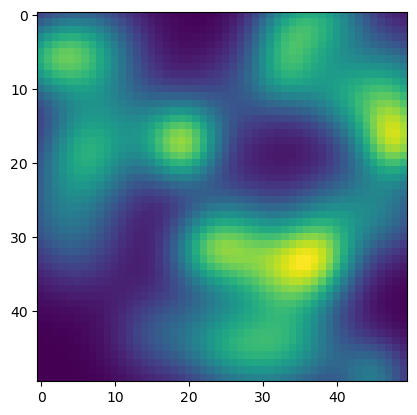

In [20]:
board = np.zeros((50,50))
board = init_background_density(board, 40)